In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import random

In [2]:
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=okabe_ito)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["TeX Gyre Pagella"],
    "text.latex.preamble": r"""
        \usepackage{amsmath}
        \usepackage{amssymb} 
        \usepackage{newpx} 
        \usepackage{icomma} 
        \usepackage{siunitx}
        \sisetup{output-decimal-marker = {,}, separate-uncertainty = true}
    """,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


## physical constants and functions that totally aren't magic

In [4]:
#masses [GeV]
m_K = 0.493677
m_pi_pm = 0.13957039
m_pi = 0.134977
m_eta = 0.547862
m_chic1 = 3.5107
m_Ds = 1.96835
m_etac = 2.9841

In [5]:
def sqrt_lambda(x, y, z):
  lmbda = x ** 2 + y ** 2 + z ** 2 - 2 * x * y - 2 * x * z - 2 * y * z
  return np.sqrt(lmbda + 0j)

def k1(s, m_pi, m_eta):
  s1 = (m_pi + m_eta) ** 2
  mu = np.sqrt(m_pi * m_eta) / (m_pi + m_eta)
  return np.where(s >= s1, mu * np.sqrt(s - s1 + 0j), mu * 1j * np.sqrt(s1 - s + 0j))

def k2(s, m_K):
  s2 = 4 * m_K ** 2
  return np.where(s >= s2, (1 / 2)* np.sqrt(s - s2 + 0j), (1 / 2) * 1j * np.sqrt(s2 - s + 0j))

def phase_space(s, M, m_s=m_pi, m_pi=m_pi, m_eta=m_eta):
  p = sqrt_lambda(s, M ** 2, m_s ** 2) / (2 * M)
  q = sqrt_lambda(s, m_pi ** 2, m_eta ** 2) / (2 * np.sqrt(s))
  return M * np.real(p * q)

def P(s, p10, p20):
  return p10, p20

def T(s, c11, c12, c22, m_pi=m_pi, m_eta=m_eta, m_K=m_K):
  num1 = c22 - 1j * k2(s, m_K)
  denom1 = (c11 - 1j * k1(s, m_pi, m_eta)) * (c22 - 1j * k2(s, m_K)) - c12 ** 2
  num2 = -c12
  denom2 = (c11 - 1j * k1(s, m_pi, m_eta)) * (c22 - 1j * k2(s, m_K)) - c12 ** 2
  return num1 / denom1, num2 / denom2

def Intensity1(E, c11, c12, c22, p10_1, p20_1):
  M = m_chic1
  s = E ** 2
  rho = phase_space(s, M=M, m_s=m_pi)
  P1, P2 = P(s, p10=p10_1, p20=p20_1)
  T1, T2 = T(s, c11=c11, c12=c12, c22=c22)
  bracket = np.abs(P1 * T1 + P2 * T2) ** 2
  return rho * bracket

def Intensity2(E, c11, c12, c22, p10_2, p20_2):
  M = m_etac
  s = E ** 2
  rho = phase_space(s, M=M, m_s=m_pi)
  P1, P2 = P(s, p10=p10_2, p20=p20_2)
  T1, T2 = T(s, c11=c11, c12=c12, c22=c22)
  bracket = np.abs(P1 * T1 + P2 * T2) ** 2
  return rho * bracket

def Intensity3(E, c11, c12, c22, p10_3, p20_3):
  M = m_chic1
  s = E ** 2
  rho = phase_space(s, M=M, m_s=m_pi)
  P1, P2 = P(s, p10=p10_3, p20=p20_3)
  T1, T2 = T(s, c11=c11, c12=c12, c22=c22)
  bracket = np.abs(P1 * T1 + P2 * T2) ** 2
  return rho * bracket

def Intensity4(E, c11, c12, c22, p10_4, p20_4):
  M = m_Ds
  s = E ** 2
  rho = phase_space(s, M=M, m_s=m_pi)
  P1, P2 = P(s, p10=p10_4, p20=p20_4)
  T1, T2 = T(s, c11=c11, c12=c12, c22=c22)
  bracket = np.abs(P1 * T1 + P2 * T2) ** 2
  return rho * bracket

def Intensity5(E, c11, c12, c22, p10_5, p20_5):
  M = m_Ds
  s = E ** 2
  rho = phase_space(s, M=M, m_s=m_pi)
  P1, P2 = P(s, p10=p10_5, p20=p20_5)
  T1, T2 = T(s, c11=c11, c12=c12, c22=c22)
  bracket = np.abs(P1 * T1 + P2 * T2) ** 2
  return rho * bracket

## bootstrap data post-cut (our targets)

In [6]:
params1 = pd.read_csv(f"./data_postcut/bs1_postcut.csv")
params2 = pd.read_csv(f"./data_postcut/bs2_postcut.csv")
params3 = pd.read_csv(f"./data_postcut/bs3_postcut.csv")
params4 = pd.read_csv(f"./data_postcut/bs4_postcut.csv")
params5 = pd.read_csv(f"./data_postcut/bs5_postcut.csv")

In [7]:
experiments = {
    1: {"model": Intensity1, "params": params1},
    2: {"model": Intensity2, "params": params2},
    3: {"model": Intensity3, "params": params3},
    4: {"model": Intensity4, "params": params4},
    5: {"model": Intensity5, "params": params5}
}

min_bins = 11
max_bins = 52
lower_th = 0.68 #[GeV]
upper_th = 1.12 #[GeV]

In [8]:
import random

selected = random.choice(list(experiments.values()))
rand_params = selected["params"].sample(n=1).iloc[0]
print(rand_params)

bins = random.randint(min_bins, max_bins)

xspace = np.linspace(lower_th, upper_th, bins)
rand_model = selected["model"]
I = rand_model(xspace, rand_params['c11'], rand_params['c12'], rand_params['c22'], rand_params.iloc[-2], rand_params.iloc[-1])

c11     -0.061398
c12     -0.283218
c22     -0.042708
p10_3   -1.611569
p20_3    4.917360
Name: 5604, dtype: float64


In [9]:
I

array([  0.        ,  24.71999861,  37.77408257,  48.29269009,
        57.89499542,  67.21052558,  76.6080139 ,  86.36522973,
        96.73284196, 107.96841161, 120.3618223 , 134.26103664,
       150.10430103, 168.46585799, 190.12637685, 216.18909611,
       248.28595042, 288.98050374, 342.68102977, 418.35121312,
       546.34738656, 397.43367978, 324.16922648, 282.58061838,
       253.56950779, 231.38672302, 213.50149874, 198.5728036 ,
       185.804072  , 174.68346777])

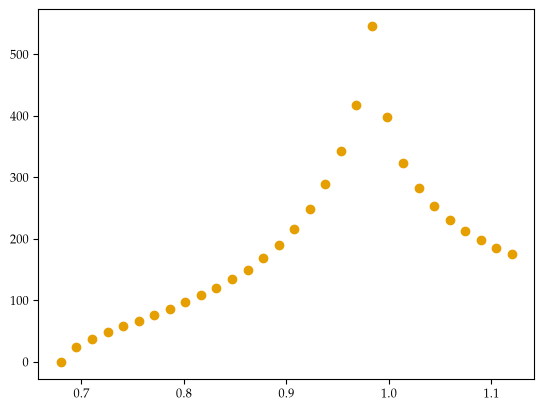

In [10]:
plt.scatter(xspace, I)

In [11]:
from torch.nn.utils.rnn import pack_padded_sequence

class LSTM_Model(nn.Module):
    def __init__(self, input_dim = 2, hidden_dim = 64, layer_dim = 2, output_dim = 3):
        super().__init__()

        """
            really bad LSTM

            input_dim: number of features at each energy step (2: (E, I))
            hidden_dim: number of features in the hidden state, hyperparameter
            layer_dim: number of LSTM layers, more is more, less is less, also adjustable hyperparameter
            output_dim: number of targets (c11, c12, c22, p10, p20)

            inspiration taken from https://www.geeksforgeeks.org/deep-learning/long-short-term-memory-networks-using-pytorch/
        """

        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim

        self.lstm = nn.LSTM(
            input_size = input_dim,
            hidden_size = hidden_dim,
            num_layers = layer_dim,
            batch_first = True # input shape: (batch, seq, input_dim)
        )

        self.fc = nn.Linear(
            hidden_dim,
            output_dim
        )

    def forward(self, x, lengths):

        """
            x: input (batch, max_seq_length, input_dim)

            lengths: original sequence lengths
        """

        pack = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first= True,
            enforce_sorted= False
        )

        _, (hidden, _) = self.lstm(pack)

        output = self.fc(hidden[-1])

        return output

In [12]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):

    sequences = []
    lengths = []
    targets = []

    for seq, target in batch:
        sequences.append(seq)
        lengths.append(len(seq))
        targets.append(target)

    paddington = pad_sequence(
        sequences,
        batch_first= True
    )

    lengths = torch.tensor(lengths)
    targets = torch.stack(targets)

    return paddington, lengths, targets

In [13]:
class IntensityData(torch.utils.data.Dataset):
    def __init__(self, experiments, n_samples, min_bins = 11, max_bins = 52, lower_th = .68, upper_th = 1.12):
        self.experiments = experiments
        self.n_samples = n_samples

        self.min_bins = min_bins
        self.max_bins = max_bins

        self.lower_th = lower_th
        self.upper_th = upper_th

        self.samples = [
            self._generate_sample()
            for _ in range(n_samples)
        ]

    def __len__(self):
        return self.n_samples

    def _generate_sample(self):
        selected = random.choice(list(self.experiments.values()))

        params = selected["params"].sample(n=1).iloc[0]

        bins = random.randint(self.min_bins, self.max_bins)

        E = np.linspace(self.lower_th, self.upper_th, bins)

        model = selected["model"]

        I = model(
            E,
            params['c11'],
            params['c12'],
            params['c22'],
            params.iloc[-2],
            params.iloc[-1]
        )

        X = np.column_stack([E, I])

        y = np.array([
            params['c11'],
            params['c12'],
            params['c22'],
        ])

        return (
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32)
        )

    def __getitem__(self, index):

        return self.samples[index]

In [14]:
class ScaledDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, mean, std):
        self.base = base_dataset
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.base)

    def __getitem__(self, index):
        features, target = self.base[index]
        features = (features - self.mean) / (self.std + 1e-8)
        return features, target

In [15]:
torch.manual_seed(1337)
random.seed(1337)
np.random.seed(1337)

dataset = IntensityData(experiments, n_samples= 50_000)

In [16]:
X, y = dataset[0]

print(X.shape)
print(y.shape)

torch.Size([45, 2])
torch.Size([3])


In [17]:
from torch.utils.data import random_split, DataLoader

train_size = int(.7 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [18]:
def compute_meanstd(dataset):
    feature_sum = torch.zeros(2)
    feature_sq_sum = torch.zeros(2)
    count = 0

    for i in range(len(dataset)):
        features, _ = dataset[i]
        feature_sum += features.sum(dim=0)  # sum over all hits, seperately for each feature
        feature_sq_sum += (features**2).sum(dim=0)
        count += features.shape[0]

    mean = feature_sum / count
    std = torch.sqrt(feature_sq_sum / count - mean**2)

    return mean, std

mean, std = compute_meanstd(train_dataset)

torch.save(
    {
        "mean": mean,
        "std": std,
    },
    "scaler.pt"
)

In [19]:
stats = torch.load("scaler.pt")
mean, std = stats["mean"], stats["std"]

train_dataset = ScaledDataset(train_dataset, mean, std)
val_dataset = ScaledDataset(val_dataset, mean, std)

In [20]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    collate_fn=collate_fn,
)

In [21]:
model = LSTM_Model().to(device)

In [22]:
loss_fn = nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr = .001)

In [23]:
number_of_epochs = 25
train_losses = []
val_losses = []

for epoch in range(number_of_epochs):
  epoch_train_loss = 0.0
  epoch_val_loss = 0.0

  model.train()

  for features, lengths, targets in train_loader:
    features = features.to(device)
    lengths = lengths.to(device)
    targets = targets.to(device)

    optimiser.zero_grad()

    preds = model(features, lengths)

    loss = loss_fn(preds, targets)

    loss.backward()
    optimiser.step()

    epoch_train_loss += loss.item()

  epoch_train_loss /= len(train_loader)
  train_losses.append(epoch_train_loss)

  model.eval()

  with torch.no_grad():
    for features, lengths, targets in val_loader:
      features = features.to(device)
      lengths = lengths.to(device)
      targets = targets.to(device)

      preds = model(features, lengths)

      loss = loss_fn(preds, targets)

      epoch_val_loss += loss.item()

  epoch_val_loss /= len(val_loader)
  val_losses.append(epoch_val_loss)

  print(f'Epoch [{epoch+1}/{number_of_epochs}], Training Loss: {epoch_train_loss:.4f}, Validation Loss: {epoch_val_loss:.4f}')

Epoch [1/25], Training Loss: 0.7403, Validation Loss: 0.7001
Epoch [2/25], Training Loss: 0.7290, Validation Loss: 0.7004
Epoch [3/25], Training Loss: 0.7256, Validation Loss: 0.7019
Epoch [4/25], Training Loss: 0.7235, Validation Loss: 0.7001
Epoch [5/25], Training Loss: 0.7228, Validation Loss: 0.6983
Epoch [6/25], Training Loss: 0.7256, Validation Loss: 0.6987
Epoch [7/25], Training Loss: 0.7229, Validation Loss: 0.6964
Epoch [8/25], Training Loss: 0.7128, Validation Loss: 0.6693
Epoch [9/25], Training Loss: 0.7099, Validation Loss: 0.6985
Epoch [10/25], Training Loss: 0.7015, Validation Loss: 0.6762
Epoch [11/25], Training Loss: 0.6949, Validation Loss: 0.6643
Epoch [12/25], Training Loss: 0.6894, Validation Loss: 0.6380
Epoch [13/25], Training Loss: 0.6524, Validation Loss: 0.6966
Epoch [14/25], Training Loss: 0.6311, Validation Loss: 0.6274
Epoch [15/25], Training Loss: 0.6139, Validation Loss: 0.5767
Epoch [16/25], Training Loss: 0.6053, Validation Loss: 0.5721
Epoch [17/25], Tr

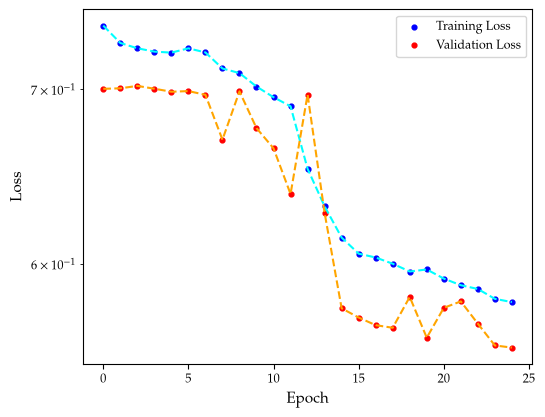

In [24]:
plt.figure(figsize=(5.8,4.6))
plt.plot(range(len(train_losses)), train_losses, color = "cyan", linestyle="--")
plt.plot(range(len(val_losses)), val_losses, color = "orange", linestyle="--")
plt.scatter(range(len(train_losses)), train_losses, color = "blue", s=12, label = "Training Loss")
plt.scatter(range(len(val_losses)), val_losses, color = "red", s=12, label = "Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.savefig("./figures/loss_curve.pdf", dpi=300)

In [25]:
torch.save(model.state_dict(), "./LSTM.pth")

## testing

In [26]:
test_dataset = IntensityData(experiments, n_samples= 1_000)
test_dataset = ScaledDataset(test_dataset, mean, std)

In [27]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn,
)

In [28]:
c11_true = []
c12_true = []
c22_true = []

c11_pred = []
c12_pred = []
c22_pred = []

with torch.no_grad():
  for features, lengths, targets in test_loader:
    features = features.to(device)
    lengths = lengths.to(device)
    targets = targets.to(device)

    preds = model(features, lengths)

    targets = targets.cpu()
    preds = preds.cpu()

    c11_true.extend(targets[:,0].tolist())
    c12_true.extend(targets[:,1].tolist())
    c22_true.extend(targets[:,2].tolist())

    c11_pred.extend(preds[:,0].tolist())
    c12_pred.extend(preds[:,1].tolist())
    c22_pred.extend(preds[:,2].tolist())

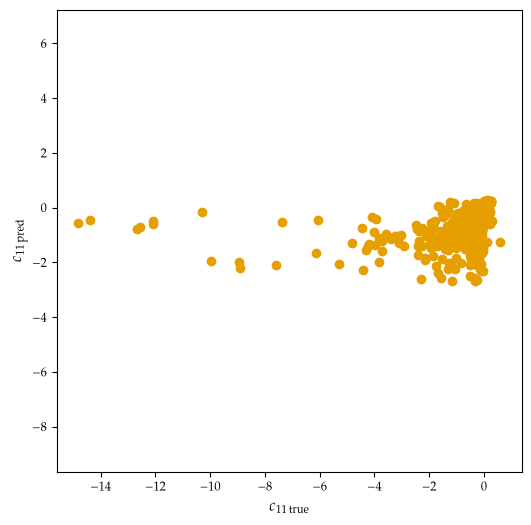

In [29]:
plt.figure(figsize=(6,6))
plt.axis("equal")
plt.scatter(c11_true, c11_pred)
plt.xlabel(r"$c_{11\,\text{true}}$")
plt.ylabel(r"$c_{11\,\text{pred}}$")
plt.savefig("./figures/c11_correlation.pdf", dpi=300)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


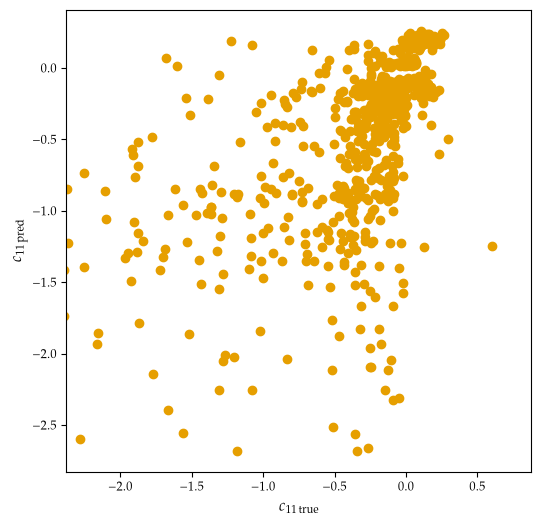

In [30]:
plt.figure(figsize=(6,6))
plt.axis("equal")
plt.xlim(-2, .5)
plt.scatter(c11_true, c11_pred)
plt.xlabel(r"$c_{11\,\text{true}}$")
plt.ylabel(r"$c_{11\,\text{pred}}$")
plt.savefig("./figures/c11_correlation.pdf", dpi=300)

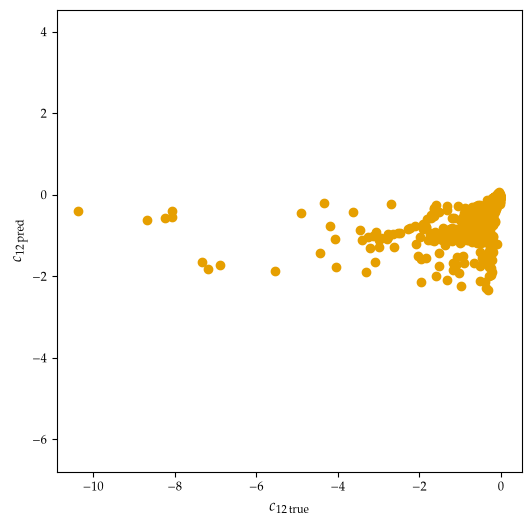

In [31]:
plt.figure(figsize=(6,6))
plt.axis("equal")
plt.scatter(c12_true, c12_pred)
plt.xlabel(r"$c_{12\,\text{true}}$")
plt.ylabel(r"$c_{12\,\text{pred}}$")
plt.savefig("./figures/c12_correlation.pdf", dpi=300)

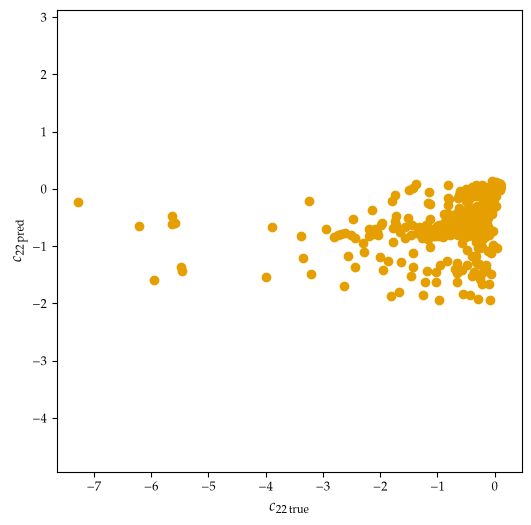

In [32]:
plt.figure(figsize=(6,6))
plt.axis("equal")
plt.scatter(c22_true, c22_pred)
plt.xlabel(r"$c_{22\,\text{true}}$")
plt.ylabel(r"$c_{22\,\text{pred}}$")
plt.savefig("./figures/c22_correlation.pdf", dpi=300)